In [1]:
# first get the mask data
import numpy as np

pacific_mask = np.load("../consts/pacific_region_mask.npy")
print(pacific_mask.shape)
twp_mask = np.load("../consts/twp_region.npy")

(96, 144)


In [6]:
# get the max and min for each coordinate in the mask
min_x = np.min(np.where(pacific_mask)[0])
max_x = np.max(np.where(pacific_mask)[0])
min_y = np.min(np.where(pacific_mask)[1])
max_y = np.max(np.where(pacific_mask)[1])
print(min_x, max_x, min_y, max_y)

35 60 46 97


In [4]:
# get the max and min for each coordinate in the mask
min_x = np.min(np.where(twp_mask)[0])
max_x = np.max(np.where(twp_mask)[0])
min_y = np.min(np.where(twp_mask)[1])
max_y = np.max(np.where(twp_mask)[1])
print(min_x, max_x, min_y, max_y)

33 61 44 98


-31.263157894736842 29.368421052631575 105.0 250.0


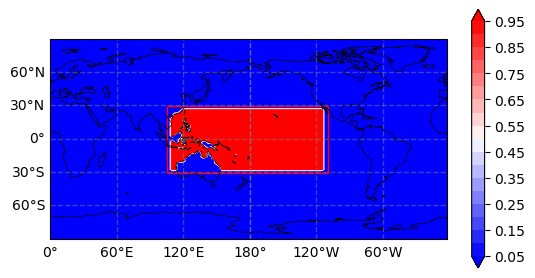

In [5]:
# plot the mask using plot_spatial
import sys
sys.path.append("../utils")
from plot_utils import plot_spatial
lon = np.linspace(0,357.5,144)
lat = np.linspace(-90,90,96)
plot_spatial(lon, lat, twp_mask)
import matplotlib.pyplot as plt
# add a rectangle box to the plot with the min and max coordinates, print coordinates for the box first
pad = 2
print(lat[min_x-pad], lat[max_x+pad], lon[min_y-pad], lon[max_y+pad])
# add the rectangle box using plot Rectangle to the plot, the transformation is projection=ccrs.PlateCarree(central_longitude=180)
import cartopy.crs as ccrs
plt.gca().add_patch(plt.Rectangle((lon[min_y-pad], lat[min_x-pad]), lon[max_y+pad]-lon[min_y-pad], lat[max_x+pad]-lat[min_x-pad], fill=None, color='r', linewidth=1, transform=ccrs.PlateCarree()))
plt.show()

-27.473684210526322 27.473684210526315 110.0 247.5


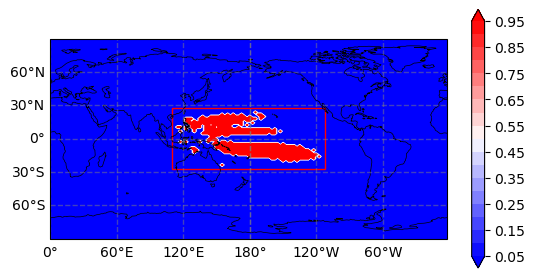

In [ ]:
# plot the mask using plot_spatial
import sys
sys.path.append("../utils")
from plot_utils import plot_spatial
lon = np.linspace(0,357.5,144)
lat = np.linspace(-90,90,96)
plot_spatial(lon, lat, pacific_mask)
import matplotlib.pyplot as plt
# add a rectangle box to the plot with the min and max coordinates, print coordinates for the box first
pad = 2
print(lat[min_x-pad], lat[max_x+pad], lon[min_y-pad], lon[max_y+pad])
# add the rectangle box using plot Rectangle to the plot, the transformation is projection=ccrs.PlateCarree(central_longitude=180)
import cartopy.crs as ccrs
plt.gca().add_patch(plt.Rectangle((lon[min_y-pad], lat[min_x-pad]), lon[max_y+pad]-lon[min_y-pad], lat[max_x+pad]-lat[min_x-pad], fill=None, color='r', linewidth=1, transform=ccrs.PlateCarree()))
plt.show()

In [8]:
# write a function that returns the min and max coordinates for the box
def get_min_max_coords(mask, pad):
    min_x = np.min(np.where(mask)[0])
    max_x = np.max(np.where(mask)[0])
    min_y = np.min(np.where(mask)[1])
    max_y = np.max(np.where(mask)[1])
    return min_x-pad, max_x+pad, min_y-pad, max_y+pad

# test the function
min_x, max_x, min_y, max_y = get_min_max_coords(pacific_mask, 2)
print(min_x, max_x, min_y, max_y)
print(lat[min_x], lat[max_x], lon[min_y], lon[max_y])
print(max_x-min_x, max_y-min_y)

33 62 44 99
-27.473684210526322 27.473684210526315 110.0 247.5
29 55


In [9]:
# write a function that returns the min and max coordinates for the box
# test the function
min_x, max_x, min_y, max_y = get_min_max_coords(twp_mask, 2)
print(min_x, max_x, min_y, max_y)
print(lat[min_x], lat[max_x], lon[min_y], lon[max_y])
print(max_x-min_x, max_y-min_y)

31 63 42 100
-31.263157894736842 29.368421052631575 105.0 250.0
32 58


In [5]:
data = pacific_mask
# get the box data from the data and then get the masked area from the box
box_data = data[min_x:max_x, min_y:max_y]
masked_area = box_data[pacific_mask[min_x:max_x, min_y:max_y].astype(bool)]
print(masked_area.shape)
print(np.mean(masked_area))

# check if the masked area is the same as the original data
print(np.sum(data[pacific_mask.astype(bool)]))


(456,)
1.0
456.0


In [6]:
import math
# write a function that returns the min and max coordinates for the box
def get_min_max_coords(mask, pad):
    min_x = np.min(np.where(mask)[0])
    max_x = np.max(np.where(mask)[0])
    min_y = np.min(np.where(mask)[1])
    max_y = np.max(np.where(mask)[1])
    wid_x = math.ceil((max_x - min_x)/2)*2
    wid_y = math.floor((max_y - min_y)/2)*2
    return int(min_x-pad), int(min_x+wid_x+pad), \
        int(min_y-pad), int(min_y+wid_y+pad)

# test the function
min_x, max_x, min_y, max_y = get_min_max_coords(pacific_mask, 3)
print(min_x, max_x, min_y, max_y)
print(lat[min_x], lat[max_x], lon[min_y], lon[max_y])
print(max_x-min_x, max_y-min_y)

32 64 43 99
-29.368421052631582 31.263157894736835 107.5 247.5
32 56


In [24]:
samples = []
import glob
all_files = glob.glob("../analysis/test_data/*.npy")
for i in range(17507,17530):
    for file_name in all_files:
        if str(i) in file_name:
            all_files.remove(file_name)

for i in ['00001', '08690', '17522', '26210', '09242']:
    for file_name in all_files:
        if i in file_name:
            all_files.remove(file_name)
all_files.sort()
for file_name in all_files[::12]:
    print(file_name)
    samples.append(np.load(file_name)[None,])
sample = np.concatenate(samples, axis=0)
print(sample.shape)

../analysis/test_data/08689.npy
../analysis/test_data/08702.npy
../analysis/test_data/08714.npy
../analysis/test_data/08726.npy
../analysis/test_data/08738.npy
../analysis/test_data/08750.npy
../analysis/test_data/08762.npy
../analysis/test_data/08774.npy
../analysis/test_data/08786.npy
../analysis/test_data/08798.npy
../analysis/test_data/08810.npy
../analysis/test_data/08822.npy
../analysis/test_data/08834.npy
../analysis/test_data/08846.npy
../analysis/test_data/08858.npy
../analysis/test_data/08870.npy
../analysis/test_data/08882.npy
../analysis/test_data/08894.npy
../analysis/test_data/08906.npy
../analysis/test_data/08918.npy
../analysis/test_data/08930.npy
../analysis/test_data/08942.npy
../analysis/test_data/08954.npy
../analysis/test_data/08966.npy
../analysis/test_data/08978.npy
../analysis/test_data/08990.npy
../analysis/test_data/09002.npy
../analysis/test_data/09014.npy
../analysis/test_data/09026.npy
../analysis/test_data/09038.npy
../analysis/test_data/09050.npy
../analy

In [12]:
import sys
sys.path.append("../dataloader")
from dataloader_utils import get_index_from_colnames

col_names = np.loadtxt("../analysis/test_data/col_names.txt", dtype=str)

In [33]:
start, end = get_index_from_colnames(col_names, "SPPS")
print(start, end)

232 233


In [25]:
sample[:,232:233].mean()

96551.31596138653

In [27]:
sample[:,232:233,pacific_mask.astype(bool)].mean()

101008.20256696429

In [29]:
sample[:,232:233,pacific_mask.astype(bool)].std()

430.0565837616595

In [30]:
sample[:,232:233, 33: 62, 44: 99].mean()

100894.39099655733

In [31]:
sample[:,232:233,33:62,44:99].std()

1144.5124050091013